# 16 — Sentence Classification with TensorFlow RNN / LSTM / GRU

**Learning objective:** Build a complete sentence-level sentiment classifier and connect the recurrent sentence representation to a binary decision.

Architecture:

```text
raw sentence (string)
   ↓ TextVectorization
token IDs
   ↓ Embedding(mask_zero=True)
token vectors
   ↓ SimpleRNN / LSTM / GRU
sentence representation
   ↓ Dense(sigmoid)
P(positive)
```

The vectorizer is adapted **only on training text** so vocabulary learning does not leak validation/test information.

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED=42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

df=pd.read_csv("RNN/data/sentence_sentiment_uci.csv")
df["stratum"]=df["source"]+"_"+df["label"].astype(str)

train,temp=train_test_split(df,test_size=.30,random_state=SEED,stratify=df["stratum"])
val,test=train_test_split(temp,test_size=.50,random_state=SEED,stratify=temp["stratum"])
print("train/val/test:",len(train),len(val),len(test))
print(train.groupby(["source","label"]).size().unstack())

2026-09-21 11:27:15.159116: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-21 11:27:15.161664: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-21 11:27:15.169870: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789990035.183749    2547 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789990035.187940    2547 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-21 11:27:15.202344: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

train/val/test: 2100 450 450
label     0    1
source          
amazon  350  350
imdb    350  350
yelp    350  350


## Why binary cross-entropy?

The final sigmoid emits a probability `p` for the positive class.

For target `y ∈ {0,1}`:

[
L = -[y\log(p) + (1-y)\log(1-p)]
]

The loss strongly penalizes confident wrong predictions.

In [2]:
MAX_TOKENS=5000
SEQ_LEN=40

vectorizer=tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LEN,
    standardize="lower_and_strip_punctuation",
)
vectorizer.adapt(train["text"].astype(str).to_numpy())
vocab=vectorizer.get_vocabulary()
print("training vocabulary size:",len(vocab))
print("vectorized shape:",vectorizer(tf.constant(train["text"].head(3).tolist())).shape)

training vocabulary size: 4306
vectorized shape: (3, 40)


2026-09-21 11:27:16.821303: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
def build_classifier(kind="GRU"):
    Layer={"SimpleRNN":tf.keras.layers.SimpleRNN,
           "LSTM":tf.keras.layers.LSTM,
           "GRU":tf.keras.layers.GRU}[kind]

    inputs=tf.keras.Input(shape=(),dtype=tf.string,name="sentence")
    x=vectorizer(inputs)
    x=tf.keras.layers.Embedding(len(vocab),32,mask_zero=True,name="embedding")(x)
    x=Layer(32,name=kind.lower())(x)
    x=tf.keras.layers.Dropout(.20)(x)
    outputs=tf.keras.layers.Dense(1,activation="sigmoid",name="positive_probability")(x)

    model=tf.keras.Model(inputs,outputs,name=f"{kind.lower()}_sentence_classifier")
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model=build_classifier("GRU")
model.summary()

Model: "gru_sentence_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sentence            │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 40)        │          0 │ sentence[0][0]    │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 40, 32)    │    137,792 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 40)        │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │      6,336 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive_probabili… │ (None, 1)         │         33 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 144,161 (563.13 KB)

 Trainable params: 144,161 (563.13 KB)

 Non-trainable params: 0 (0.00 B)

epochs trained: 5
best validation accuracy: 0.8044


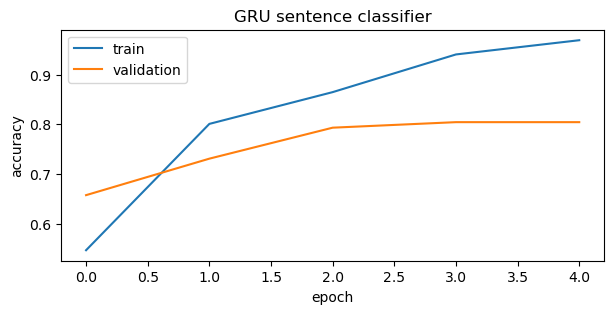

In [4]:
history=model.fit(
    train["text"].astype(str).to_numpy(),
    train["label"].to_numpy(),
    validation_data=(val["text"].astype(str).to_numpy(),val["label"].to_numpy()),
    epochs=8,
    batch_size=64,
    verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",patience=2,restore_best_weights=True
    )]
)
print("epochs trained:",len(history.history["loss"]))
print("best validation accuracy:",round(max(history.history["val_accuracy"]),4))

plt.figure(figsize=(7,3))
plt.plot(history.history["accuracy"],label="train")
plt.plot(history.history["val_accuracy"],label="validation")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("GRU sentence classifier"); plt.legend(); plt.show()

validation accuracy: 0.7933
              precision    recall  f1-score   support

    negative      0.787     0.804     0.796       225
    positive      0.800     0.782     0.791       225

    accuracy                          0.793       450
   macro avg      0.793     0.793     0.793       450
weighted avg      0.793     0.793     0.793       450



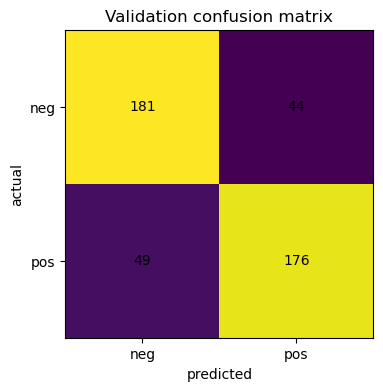

In [5]:
val_prob=model.predict(val["text"].astype(str).to_numpy(),verbose=0).ravel()
val_pred=(val_prob>=.5).astype(int)
print("validation accuracy:",round(accuracy_score(val["label"],val_pred),4))
print(classification_report(val["label"],val_pred,target_names=["negative","positive"],digits=3))

cm=confusion_matrix(val["label"],val_pred)
plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.xticks([0,1],["neg","pos"]); plt.yticks([0,1],["neg","pos"])
plt.xlabel("predicted"); plt.ylabel("actual"); plt.title("Validation confusion matrix")
for i in range(2):
    for j in range(2): plt.text(j,i,cm[i,j],ha="center",va="center")
plt.show()

In [6]:
samples=tf.constant([
    "The acting was wonderful and I loved the story.",
    "The product failed after one day and was a waste of money.",
    "The food was okay but the service was painfully slow."
],dtype=tf.string)
p=model(samples,training=False).numpy().ravel()
for s,prob in zip(samples.numpy(),p):
    print(f"{prob:.3f} positive | {s.decode()}")

0.792 positive | The acting was wonderful and I loved the story.
0.139 positive | The product failed after one day and was a waste of money.
0.094 positive | The food was okay but the service was painfully slow.


## Engineering interpretation

The classifier accepts **raw strings** because preprocessing is part of the model graph. That reduces training/inference skew.

### When an RNN is useful for text
- students need to understand sequential state directly;
- sequence lengths are moderate;
- compact recurrent architectures are sufficient;
- order-dependent patterns matter.

### When to consider another architecture
For very long contexts and highly parallel large-scale NLP, transformer architectures are often more appropriate.

The flagship project now compares SimpleRNN, LSTM and GRU systematically, selects using validation data only, and evaluates once on an untouched test set.